# Extended Figure 14: Barcoding Screen Validation

Kexin Dong

Last update: June 2026

In [6]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

In [7]:
# ── Library ───────────────────────────────────────────────────────────────────
LIB     = pd.read_csv(BASE + 'MBESv2_focused.csv', index_col=0)
LIB_OG  = pd.read_csv(BASE + 'MBESv2_CORRECTED.csv')

BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':         pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':         pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0':     {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC':     {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':      {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':      {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                       'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    # FSR screens — d15 cols are 'd15-1','d15-2','d15-3'
    'ABE_EPO_T0_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_T0_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_EPO_BC_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_BC_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_BC_T0_FSR':  {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_BC_T0_FSR':  {'bm':    ['bm2','bm3','bm4','bm5'],
                       'spleen':['spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')


Loaded:
  ABE_OG: 1070 guides
  CBE_OG: 13242 guides
  ABE_EPO_T0: 376 guides
  CBE_EPO_T0: 1257 guides
  ABE_EPO_BC: 376 guides
  CBE_EPO_BC: 1257 guides
  ABE_BC_T0: 376 guides
  CBE_BC_T0: 1257 guides
  ABE_EPO_T0_FSR: 376 guides
  CBE_EPO_T0_FSR: 1257 guides
  ABE_EPO_BC_FSR: 376 guides
  CBE_EPO_BC_FSR: 1257 guides
  ABE_BC_T0_FSR: 376 guides
  CBE_BC_T0_FSR: 1257 guides


In [8]:
# ── Guide lists ──────────────────────────────────────────────────────────────
targeting_names = ['targeting guide', 'essential truncation guide']
control_names   = ['safe-targeting control', 'non-targeting control']

guides_targ    = LIB[LIB['classification'].isin(targeting_names)]['gRNA_id']
guides_nontarg = LIB[LIB['classification'].isin(control_names)]['gRNA_id']

# OG library ABE guide lists
ABE_OG_targ    = dfs['ABE_OG'][dfs['ABE_OG']['gRNA_id'].isin(guides_targ)]
ABE_OG_nontarg = dfs['ABE_OG'][dfs['ABE_OG']['gRNA_id'].isin(guides_nontarg)]

# Display name maps
name_dict_v1 = {'d5': 'Day 5', 'd15': 'Day 15', 'spleen': 'Spleen', 'bm': 'Bone Marrow'}
name_dict_v2 = {'d15': 'Day 15', 'spleen': 'Spleen', 'bm': 'Bone Marrow'}
conds_v1     = ['d15', 'bm', 'spleen']   # conditions with FDR in focused screens
conds_v2     = ['d15', 'bm', 'spleen']   # same set for FSR screens

## Analysis 1: NT LFC distribution — ABE v1 (T0) and ABE v2 FSR (T0)

Compare targeting vs non-targeting guide LFC distributions to verify null guide quality.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


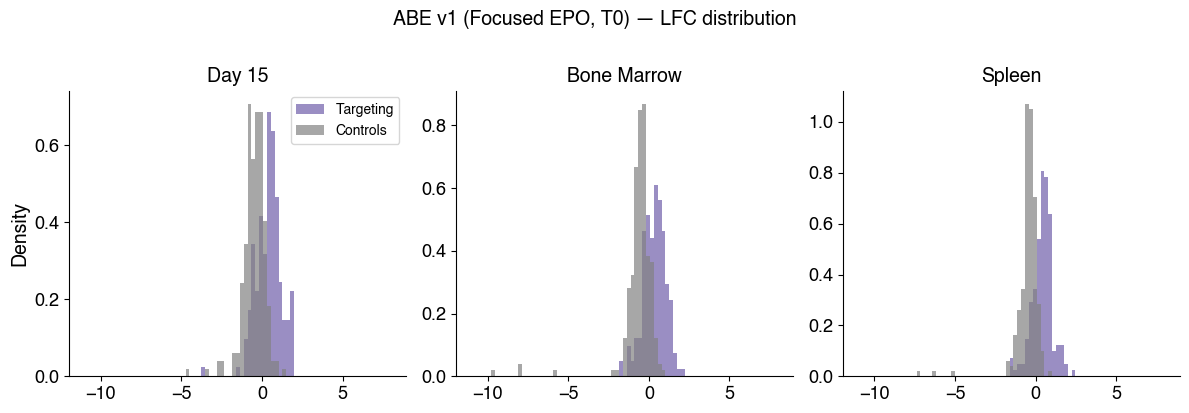

In [9]:
# ABE v1 focused EPO (T0-normalised)
df_v1 = dfs['ABE_EPO_T0']
v1_targ    = df_v1[df_v1['gRNA_id'].isin(guides_targ)]
v1_nontarg = df_v1[df_v1['gRNA_id'].isin(guides_nontarg)]

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=False)
bins = np.linspace(-11, 8, 80)

for idx, cond in enumerate(conds_v1):
    ax[idx].hist(v1_targ[f'LFC_median_{cond}'],    density=True, bins=bins,
                 alpha=0.7, color=purples[4], label='Targeting')
    ax[idx].hist(v1_nontarg[f'LFC_median_{cond}'], density=True, bins=bins,
                 alpha=0.7, color=greys[3],   label='Controls')
    ax[idx].set_title(name_dict_v1[cond], fontsize=14)
    ax[idx].spines[['top', 'right']].set_visible(False)
    ax[idx].tick_params(labelsize=13)
    ax[idx].set_xticks([-10, -5, 0, 5])

ax[0].set_ylabel('Density', fontsize=14)
ax[0].legend(fontsize=10)
fig.suptitle('ABE v1 (Focused EPO, T0) — LFC distribution', fontsize=14, y=1.02)
fig.tight_layout()
os.makedirs(BASE + 'figures/extended/fig14', exist_ok=True)
fig.savefig(BASE + 'figures/extended/fig14/analysis1_abe_v1_T0.pdf', bbox_inches='tight')
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


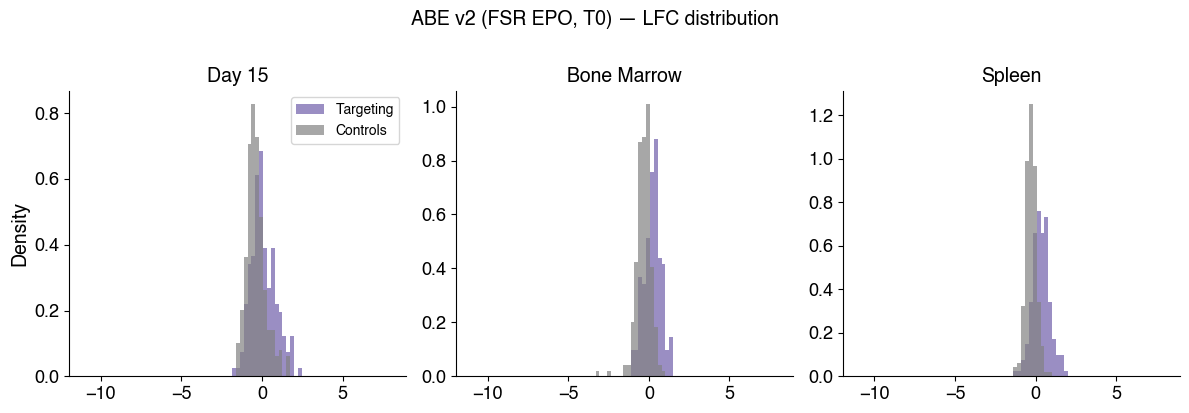

In [140]:
# ABE v2 FSR EPO (T0-normalised)
df_v2 = dfs['ABE_EPO_T0_FSR']
v2_targ    = df_v2[df_v2['gRNA_id'].isin(guides_targ)]
v2_nontarg = df_v2[df_v2['gRNA_id'].isin(guides_nontarg)]

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=False)
bins = np.linspace(-11, 8, 80)

for idx, cond in enumerate(conds_v2):
    ax[idx].hist(v2_targ[f'LFC_median_{cond}'],    density=True, bins=bins,
                 alpha=0.7, color=purples[4], label='Targeting')
    ax[idx].hist(v2_nontarg[f'LFC_median_{cond}'], density=True, bins=bins,
                 alpha=0.7, color=greys[3],   label='Controls')
    ax[idx].set_title(name_dict_v2[cond], fontsize=14)
    ax[idx].spines[['top', 'right']].set_visible(False)
    ax[idx].tick_params(labelsize=13)
    ax[idx].set_xticks([-10, -5, 0, 5])

ax[0].set_ylabel('Density', fontsize=14)
ax[0].legend(fontsize=10)
fig.suptitle('ABE v2 (FSR EPO, T0) — LFC distribution', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(BASE + 'figures/extended/fig14/analysis1_abe_v2_T0.pdf', bbox_inches='tight')
plt.show()

## Analysis 2: NT z-score correlation — T0 vs BC normalisation

Each point = one non-targeting guide. High correlation validates BC normalization.
Performed for both ABE v1 (focused) and ABE v2 (FSR).

In [12]:
def z_score(df, conditions):
    df = df.copy()
    for cond in conditions:
        col = f'LFC_median_{cond}'
        df[f'z_score_{cond}'] = (df[col] - df[col].mean()) / df[col].std()
    return df

def scatter_t0_vs_bc_2row(t0_v1, bc_v1, t0_v2, bc_v2, conditions, savepath):
    """2x3 grid: row 0 = v1, row 1 = v2; shared x/y across all panels."""
    color_dict_nt = {'non-targeting control': greens[4], 'safe-targeting control': yellows[4]}
    rows = [
        ('ABE v1 (Focused)', t0_v1, bc_v1),
        ('ABE v2 (FSR)',     t0_v2, bc_v2),
    ]
    fig, axes = plt.subplots(2, len(conditions), figsize=(4 * len(conditions), 8),
                             )

    for row_idx, (row_label, t0_df, bc_df) in enumerate(rows):
        t0_z = z_score(t0_df[t0_df['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True), conditions)
        bc_z = z_score(bc_df[bc_df['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True), conditions)

        for col_idx, cond in enumerate(conditions):
            ax = axes[row_idx][col_idx]
            t0 = t0_z[['gRNA_id', f'z_score_{cond}', 'classification']].rename(
                        columns={f'z_score_{cond}': 't0_z'})
            bc = bc_z[['gRNA_id', f'z_score_{cond}']].rename(
                        columns={f'z_score_{cond}': 'bc_z'})
            df = pd.merge(t0, bc, on='gRNA_id')

            rs, _ = scipy.stats.spearmanr(df['t0_z'], df['bc_z'])
            rp, _ = scipy.stats.pearsonr(df['t0_z'],  df['bc_z'])

            show_legend = (row_idx == 0 and col_idx == len(conditions) - 1)
            sns.scatterplot(data=df, x='t0_z', y='bc_z', ax=ax,
                            hue='classification', palette=color_dict_nt,
                            s=60, alpha=0.6, legend=show_legend)
            ax.axline((0, 0), slope=1, ls='--', color='gray', lw=1)
            ax.axhline(0, color='gray', lw=0.8, ls='--')
            ax.axvline(0, color='gray', lw=0.8, ls='--')
            ax.set_title(f'{name_dict_v1.get(cond, cond)}\n$R_p={rp:.2f}\,|\,R_s={rs:.2f}$', fontsize=13)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=13)
            ax.set_xlabel('Z-score EPO (T0)' if row_idx == 1 else '', fontsize=13)
            ax.set_ylabel(f'{row_label}\nZ-score EPO (BC)' if col_idx == 0 else '', fontsize=13)

    if axes[0][-1].get_legend():
        axes[0][-1].legend(fontsize=9, loc='upper left')

    # Unified axis limits across all panels (exclude top 1% outliers)
    all_vals = np.concatenate([ax.get_xlim() + ax.get_ylim() for ax in axes.flat])
    lim = np.percentile(np.abs(all_vals), 98) + 0.3
    for ax in axes.flat:
        ax.set_aspect('equal', adjustable='box')

    fig.suptitle('NT guide z-score: T0 vs BC normalisation', fontsize=14)
    fig.tight_layout()
    os.makedirs(BASE + 'figures/extended/fig14', exist_ok=True)
    fig.savefig(savepath, bbox_inches='tight')
    plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


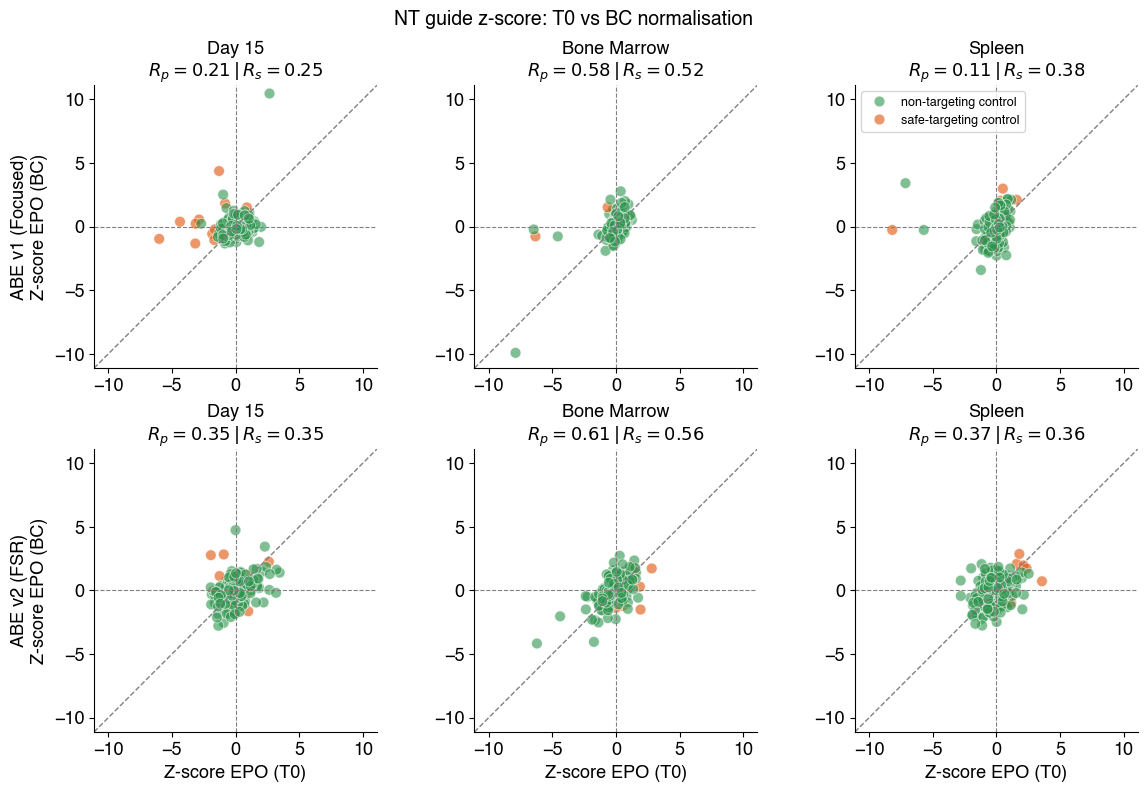

In [142]:
scatter_t0_vs_bc_2row(
    t0_v1    = dfs['ABE_EPO_T0'],
    bc_v1    = dfs['ABE_EPO_BC'],
    t0_v2    = dfs['ABE_EPO_T0_FSR'],
    bc_v2    = dfs['ABE_EPO_BC_FSR'],
    conditions = conds_v1,
    savepath = BASE + 'figures/extended/fig14/analysis2_nt_corr.pdf',
)

<!-- merged into cell above -->

## Analysis 3: Identify outlier NT guides and show FDR distribution improvement

NT guides in bottom 5% of z-scores in **both** T0 and BC screens (any tissue) are flagged.
FDR is recalculated after removing them. Performed for ABE v1 and ABE v2 (FSR).

In [143]:
def find_outlier_nts(t0_df, bc_df, conditions):
    """Return list of NT guide IDs in bottom 5% z-score in BOTH screens for ANY tissue."""
    t0_z = z_score(t0_df[t0_df['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True), conditions)
    bc_z = z_score(bc_df[bc_df['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True), conditions)

    removed = []
    for cond in conditions:
        t0 = t0_z[['gRNA_id', f'z_score_{cond}']].rename(columns={f'z_score_{cond}': 't0_z'})
        bc = bc_z[['gRNA_id', f'z_score_{cond}']].rename(columns={f'z_score_{cond}': 'bc_z'})
        df = pd.merge(t0, bc, on='gRNA_id')
        q_t0 = df['t0_z'].quantile(0.05)
        q_bc  = df['bc_z'].quantile(0.05)
        outliers = df[(df['t0_z'] <= q_t0) & (df['bc_z'] <= q_bc)]['gRNA_id'].tolist()
        removed.extend(outliers)
        print(f'  {cond}: {len(outliers)} outlier NTs')

    removed = list(set(removed))
    print(f'  Total unique: {len(removed)}')
    return removed

print('ABE v1 outlier NTs:')
abe_v1_removed = find_outlier_nts(dfs['ABE_EPO_T0'], dfs['ABE_EPO_BC'], conds_v1)

print('\nABE v2 (FSR) outlier NTs:')
abe_v2_removed = find_outlier_nts(dfs['ABE_EPO_T0_FSR'], dfs['ABE_EPO_BC_FSR'], conds_v2)

ABE v1 outlier NTs:
  d15: 2 outlier NTs
  bm: 2 outlier NTs
  spleen: 2 outlier NTs
  Total unique: 6

ABE v2 (FSR) outlier NTs:
  d15: 1 outlier NTs
  bm: 5 outlier NTs
  spleen: 3 outlier NTs
  Total unique: 8


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


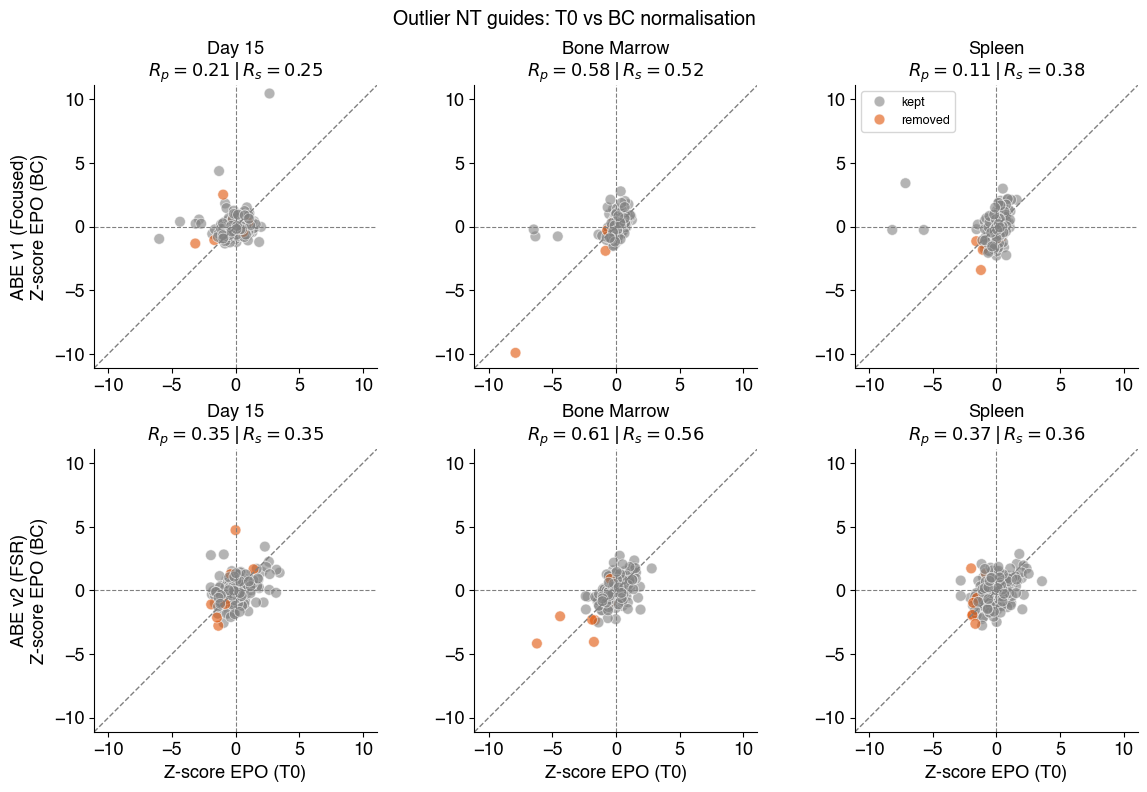

In [144]:
def scatter_outliers_2row(t0_v1, bc_v1, removed_v1, t0_v2, bc_v2, removed_v2, conditions, savepath):
    """2x3 grid: row 0 = v1, row 1 = v2; shared x/y; outliers highlighted."""
    color_removed = {'removed': yellows[4], 'kept': greys[3]}
    rows = [
        ('ABE v1 (Focused)', t0_v1, bc_v1, removed_v1),
        ('ABE v2 (FSR)',     t0_v2, bc_v2, removed_v2),
    ]
    fig, axes = plt.subplots(2, len(conditions), figsize=(4 * len(conditions), 8),
                             )

    for row_idx, (row_label, t0_df, bc_df, removed) in enumerate(rows):
        t0_z = z_score(t0_df[t0_df['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True), conditions)
        bc_z = z_score(bc_df[bc_df['gRNA_id'].isin(guides_nontarg)].reset_index(drop=True), conditions)

        for col_idx, cond in enumerate(conditions):
            ax = axes[row_idx][col_idx]
            t0 = t0_z[['gRNA_id', f'z_score_{cond}']].rename(columns={f'z_score_{cond}': 't0_z'})
            bc = bc_z[['gRNA_id', f'z_score_{cond}']].rename(columns={f'z_score_{cond}': 'bc_z'})
            df = pd.merge(t0, bc, on='gRNA_id')
            df['status'] = np.where(df['gRNA_id'].isin(removed), 'removed', 'kept')

            rs, _ = scipy.stats.spearmanr(df['t0_z'], df['bc_z'])
            rp, _ = scipy.stats.pearsonr(df['t0_z'],  df['bc_z'])

            show_legend = (row_idx == 0 and col_idx == len(conditions) - 1)
            sns.scatterplot(data=df, x='t0_z', y='bc_z', hue='status',
                            palette=color_removed, ax=ax, s=60, alpha=0.6,
                            legend=show_legend)
            ax.axline((0, 0), slope=1, ls='--', color='gray', lw=1)
            ax.axhline(0, color='gray', lw=0.8, ls='--')
            ax.axvline(0, color='gray', lw=0.8, ls='--')
            ax.set_title(f'{name_dict_v1.get(cond, cond)}\n$R_p={rp:.2f}\,|\,R_s={rs:.2f}$', fontsize=13)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=13)
            ax.set_xlabel('Z-score EPO (T0)' if row_idx == 1 else '', fontsize=13)
            ax.set_ylabel(f'{row_label}\nZ-score EPO (BC)' if col_idx == 0 else '', fontsize=13)

    if axes[0][-1].get_legend():
        axes[0][-1].legend(fontsize=9, loc='upper left')

    # Unified axis limits across all panels (exclude top 1% outliers)
    all_vals = np.concatenate([ax.get_xlim() + ax.get_ylim() for ax in axes.flat])
    lim = np.percentile(np.abs(all_vals), 98) + 0.3
    for ax in axes.flat:
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal', adjustable='box')

    fig.suptitle('Outlier NT guides: T0 vs BC normalisation', fontsize=14)
    fig.tight_layout()
    os.makedirs(BASE + 'figures/extended/fig14', exist_ok=True)
    fig.savefig(savepath, bbox_inches='tight')
    plt.show()

scatter_outliers_2row(
    t0_v1    = dfs['ABE_EPO_T0'],
    bc_v1    = dfs['ABE_EPO_BC'],
    removed_v1 = abe_v1_removed,
    t0_v2    = dfs['ABE_EPO_T0_FSR'],
    bc_v2    = dfs['ABE_EPO_BC_FSR'],
    removed_v2 = abe_v2_removed,
    conditions = conds_v1,
    savepath = BASE + 'figures/extended/fig14/analysis3_outliers.pdf',
)

In [145]:
def plot_fdr_comparison_2row(orig_v1, cleaned_v1, orig_v2, cleaned_v2, conditions, savepath):
    """2xN grid: row 0 = v1, row 1 = v2; unified x axis per column."""
    def shared_bins(a, b, n=20):
        a, b = np.asarray(a)[np.isfinite(a)], np.asarray(b)[np.isfinite(b)]
        lo = min(a.min() if a.size else 0, b.min() if b.size else 0)
        hi = max(a.max() if a.size else 1, b.max() if b.size else 1)
        if lo == hi:
            lo, hi = lo - 0.5, hi + 0.5
        return np.linspace(lo, hi, n + 1)

    rows = [
        ('ABE v1 (Focused)', orig_v1, cleaned_v1),
        ('ABE v2 (FSR)',     orig_v2, cleaned_v2),
    ]
    fig, axes = plt.subplots(2, len(conditions), figsize=(4 * len(conditions), 8),
                             sharex='col', sharey=False)

    for row_idx, (row_label, df_orig, df_cleaned) in enumerate(rows):
        for col_idx, cond in enumerate(conditions):
            ax = axes[row_idx][col_idx]
            col = f'FDR_{cond}_fishers'
            x_all     = df_orig[col].dropna().values    if col in df_orig.columns    else np.array([])
            x_cleaned = df_cleaned[col].dropna().values if col in df_cleaned.columns else np.array([])
            bins = shared_bins(x_all, x_cleaned)

            ax.hist(x_all,     bins=bins, density=True, alpha=0.5, color=blues[4],   label='All NTs')
            ax.hist(x_cleaned, bins=bins, density=True, alpha=0.5, color=yellows[4], label='Outliers removed')
            sns.kdeplot(x=x_all,     ax=ax, color=blues[4],   lw=2)
            sns.kdeplot(x=x_cleaned, ax=ax, color=yellows[4], lw=2)

            ax.set_title(name_dict_v1.get(cond, cond), fontsize=13)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=13)
            ax.set_xlabel('FDR' if row_idx == 1 else '', fontsize=13)
            ax.set_ylabel(f'{row_label}\nDensity' if col_idx == 0 else '', fontsize=13)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, fontsize=11,
               bbox_to_anchor=(0.5, 1.01))
    fig.suptitle('FDR distribution: all NTs vs outlier-removed', fontsize=14, y=1.04)
    fig.tight_layout()
    os.makedirs(BASE + 'figures/extended/fig14', exist_ok=True)
    fig.savefig(savepath, bbox_inches='tight')
    plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


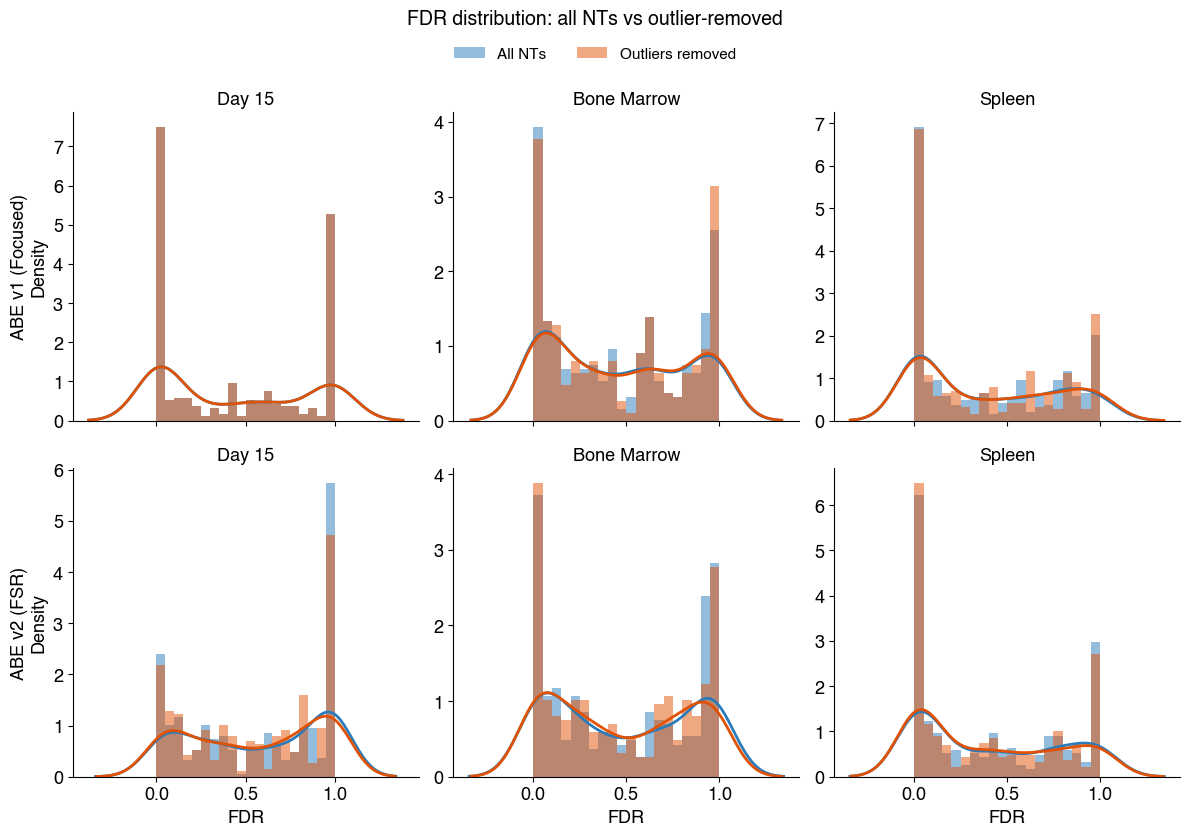

In [146]:
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests
np.random.seed(0)

def recalc_fdr(lfc_df, removed_ids, samp_dict, conditions):
    """Recalculate FDR after removing outlier NTs from bootstrapped null."""
    def emp_pval(obs, null):
        N = len(null)
        return (np.sum(null >= obs) + 1) / (N + 1), (np.sum(null <= obs) + 1) / (N + 1)

    controls = lfc_df[
        lfc_df['gRNA_id'].isin(guides_nontarg) &
        ~lfc_df['gRNA_id'].isin(removed_ids)
    ].reset_index(drop=True)

    null_dict = {}
    for cond in conditions:
        reps = [r for r in samp_dict.get(cond, []) if r in lfc_df.columns]
        if not reps:
            continue
        vals = controls[reps].to_numpy().flatten()
        null_dict[cond] = np.random.choice(vals, size=10_000, replace=True)

    result = lfc_df.copy()
    for cond in conditions:
        if cond not in null_dict:
            continue
        null = null_dict[cond]
        reps = [r for r in samp_dict.get(cond, []) if r in lfc_df.columns]
        values = np.asarray(result[reps])
        ph = np.array([[emp_pval(v, null)[0] for v in row] for row in values])
        pl = np.array([[emp_pval(v, null)[1] for v in row] for row in values])
        fdr_h = multipletests(np.array([combine_pvalues(r, method='fisher')[1] for r in ph]), method='fdr_bh')[1]
        fdr_l = multipletests(np.array([combine_pvalues(r, method='fisher')[1] for r in pl]), method='fdr_bh')[1]
        result[f'FDR_{cond}_fishers'] = np.minimum(fdr_h, fdr_l)
    return result

# v1
ABE_v1_fdr_cleaned = recalc_fdr(dfs['ABE_EPO_T0'], abe_v1_removed, rep_cols['ABE_EPO_T0'], conds_v1)
# v2
ABE_v2_fdr_cleaned = recalc_fdr(dfs['ABE_EPO_T0_FSR'], abe_v2_removed, rep_cols['ABE_EPO_T0_FSR'], conds_v2)

plot_fdr_comparison_2row(
    orig_v1    = dfs['ABE_EPO_T0'],
    cleaned_v1 = ABE_v1_fdr_cleaned,
    orig_v2    = dfs['ABE_EPO_T0_FSR'],
    cleaned_v2 = ABE_v2_fdr_cleaned,
    conditions = conds_v1,
    savepath   = BASE + 'figures/extended/fig14/analysis3_fdr.pdf',
)

## Analysis 4: Targeting guide z-score correlation — T0 vs BC normalisation (v1 and v2)

Each point = one targeting guide. High correlation validates that BC and T0 normalisations
give consistent LFC estimates for the targeting guides used in the screen.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


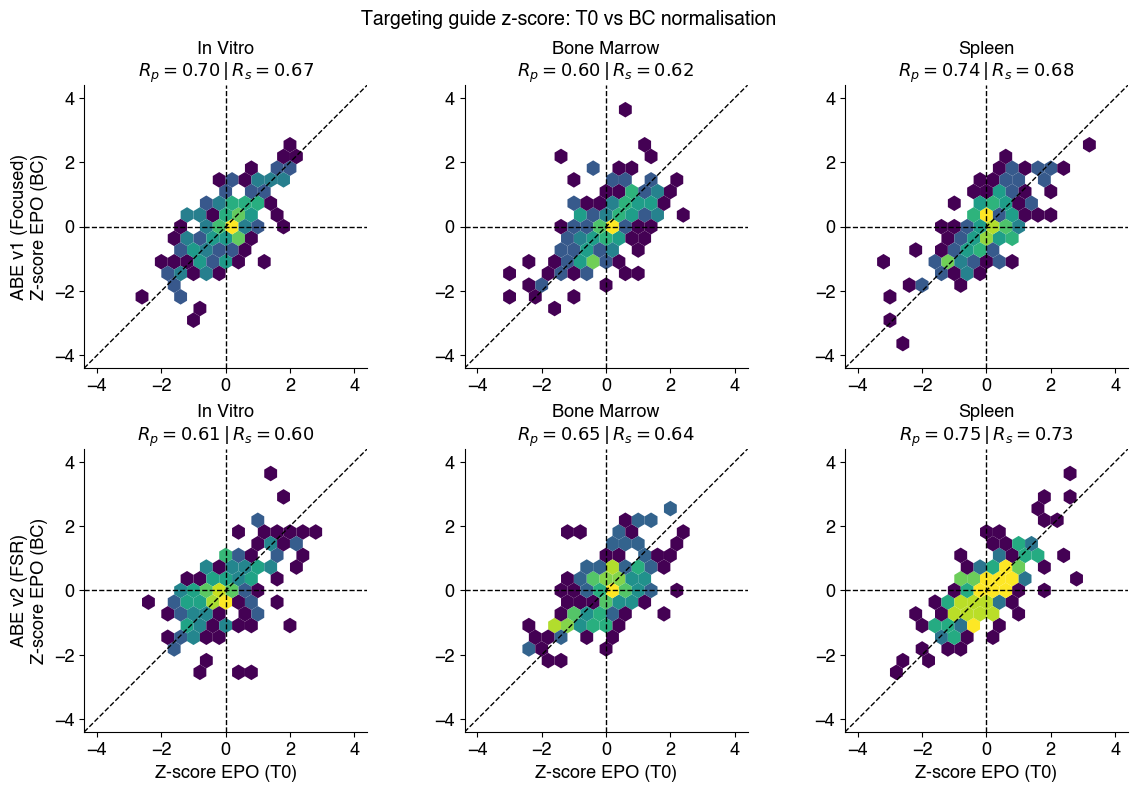

In [147]:
def scatter_targ_2row(t0_v1, bc_v1, t0_v2, bc_v2, conds_v1, conds_v2, savepath):
    """2xN hexbin scatter: row 0 = v1 (4 tissues), row 1 = v2 (3 tissues).
    Panels within each row share x/y; unified lim set after drawing."""
    name_dict_all = {'d15': 'In Vitro', 'bm': 'Bone Marrow',
                     'spleen': 'Spleen', 'men': 'Meninges'}

    # z-score targeting guides only
    def prep(df, conditions):
        d = z_score(df[df['gRNA_id'].isin(guides_targ)].reset_index(drop=True), conditions)
        return d

    rows = [
        (t0_v1, bc_v1, conds_v1, 'ABE v1 (Focused)'),
        (t0_v2, bc_v2, conds_v2, 'ABE v2 (FSR)'),
    ]
    ncols = max(len(conds_v1), len(conds_v2))
    fig, axes = plt.subplots(2, ncols, figsize=(4 * ncols, 8))

    for row_idx, (t0_df, bc_df, conditions, row_label) in enumerate(rows):
        t0_z = prep(t0_df, conditions)
        bc_z = prep(bc_df, conditions)

        for col_idx in range(ncols):
            ax = axes[row_idx][col_idx]
            if col_idx >= len(conditions):
                ax.set_visible(False)
                continue

            cond = conditions[col_idx]
            t0 = t0_z[['gRNA_id', f'z_score_{cond}']].rename(columns={f'z_score_{cond}': 't0_z'})
            bc = bc_z[['gRNA_id', f'z_score_{cond}']].rename(columns={f'z_score_{cond}': 'bc_z'})
            df = pd.merge(t0, bc, on='gRNA_id')

            rs, _ = scipy.stats.spearmanr(df['t0_z'], df['bc_z'])
            rp, _ = scipy.stats.pearsonr(df['t0_z'],  df['bc_z'])

            ax.hexbin(df['t0_z'], df['bc_z'], bins='log', gridsize=20, linewidth=0,
                      extent=(-4, 4, -4, 4))
            ax.axline((0, 0), slope=1, ls='--', color='black', lw=1)
            ax.axhline(0, ls='--', color='black', lw=1)
            ax.axvline(0, ls='--', color='black', lw=1)
            ax.set_title(f'{name_dict_all.get(cond, cond)}\n$R_p={rp:.2f}\,|\,R_s={rs:.2f}$', fontsize=13)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=13)
            ax.set_xlabel('Z-score EPO (T0)' if row_idx == 1 else '', fontsize=13)
            ax.set_ylabel(f'{row_label}\nZ-score EPO (BC)' if col_idx == 0 else '', fontsize=13)
            ax.set_aspect('equal', adjustable='box')

    fig.suptitle('Targeting guide z-score: T0 vs BC normalisation', fontsize=14)
    fig.tight_layout()
    os.makedirs(BASE + 'figures/extended/fig14', exist_ok=True)
    fig.savefig(savepath, bbox_inches='tight')
    plt.show()

scatter_targ_2row(
    t0_v1    = dfs['ABE_EPO_T0'],
    bc_v1    = dfs['ABE_EPO_BC'],
    t0_v2    = dfs['ABE_EPO_T0_FSR'],
    bc_v2    = dfs['ABE_EPO_BC_FSR'],
    conds_v1 = ['d15', 'bm', 'spleen'],
    conds_v2 = ['d15', 'bm', 'spleen'],
    savepath = BASE + 'figures/extended/fig14/analysis4_targ_corr.pdf',
)

## Analysis 5: heatmaps of top10 OG ABE enrichers in spleen, OG, v1 T0, v2 T0, v1 BC, v2 BC

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


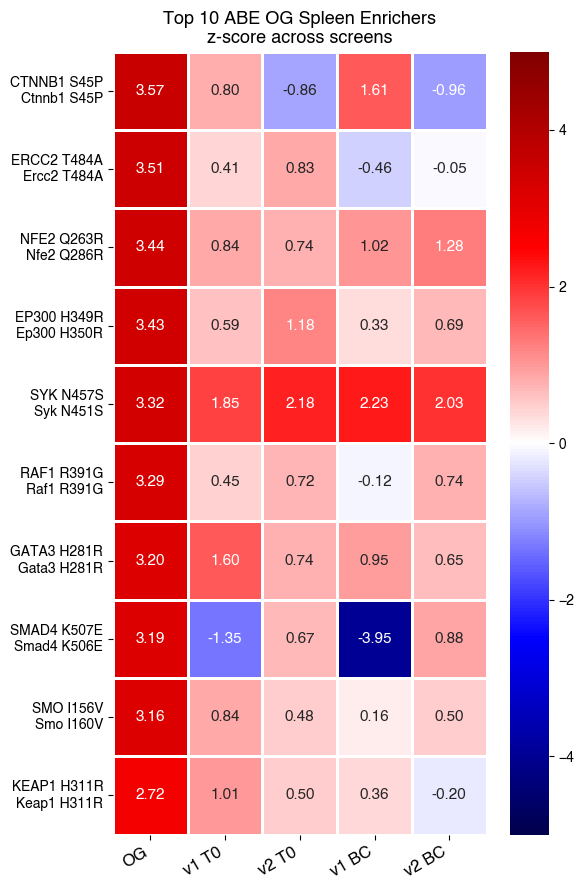

In [148]:
# ── Analysis 5: Top 10 OG ABE spleen enrichers — heatmap across 5 screens ──────────
FDR_cutoff  = 0.1
LFC_cutoff  = 1.0
min_edit    = 10.0   # target_base_edit_perc
min_input   = 2      # Input_median
min_sensor_og = 10   # sensor_reads for OG screen

cond_sort = 'spleen'   # rank by spleen z-score

# ── 1. Filter OG targeting guides that are spleen enrichers ──────────────────
og = dfs['ABE_OG'][dfs['ABE_OG']['classification'] == 'targeting guide'].copy()
og = og[og['Input_median'] >= min_input]
if f'sensor_reads_{cond_sort}' in og.columns:
    og = og[og[f'sensor_reads_{cond_sort}'] >= min_sensor_og]
og = og[
    (og[f'target_base_edit_perc_{cond_sort}'] >= min_edit) &
    (og[f'FDR_{cond_sort}_fishers']           <= FDR_cutoff) &
    (og[f'LFC_median_{cond_sort}']             >= LFC_cutoff)
].copy()
og = og.sort_values(by=f'z_score_median_{cond_sort}', ascending=False).reset_index(drop=True)
top = og.iloc[:10].copy()

# ── 2. Pull z-scores from each focused screen for the same guide IDs ─────────
def pull_z(df_key, cond, col_rename):
    df = dfs[df_key]
    col = f'z_score_median_{cond}'
    if col not in df.columns:
        return pd.Series([float('nan')] * len(top), name=col_rename)
    return df.set_index('gRNA_id')[col].reindex(top['gRNA_id']).reset_index(drop=True).rename(col_rename)

heat_data = pd.DataFrame({
    'OG':    og.set_index('gRNA_id')[f'z_score_median_{cond_sort}'].reindex(top['gRNA_id']).values,
    'v1 T0': pull_z('ABE_EPO_T0',     cond_sort, 'v1 T0').values,
    'v2 T0': pull_z('ABE_EPO_T0_FSR', cond_sort, 'v2 T0').values,
    'v1 BC': pull_z('ABE_EPO_BC',     cond_sort, 'v1 BC').values,
    'v2 BC': pull_z('ABE_EPO_BC_FSR', cond_sort, 'v2 BC').values,
})

# ── 3. Y-axis labels: human gene + HGVSp / mouse gene + HGVSp ────────────────
labels = []
for _, row in top.iterrows():
    hgvs_h = row['HGVSp_h'] if isinstance(row.get('HGVSp_h'), str) else 'Non-coding'
    hgvs_m = row['HGVSp_m'] if isinstance(row.get('HGVSp_m'), str) else ''
    gene_h = row.get('gene_name_h', row.get('Gene', ''))
    gene_m = row.get('Gene', '')
    labels.append(f"{gene_h} {hgvs_h}\n{gene_m} {hgvs_m}".strip())

# ── 4. Draw heatmap ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 9))
g = sns.heatmap(
    heat_data,
    cmap='seismic', annot=True, fmt='.2f', annot_kws={'size': 11},
    linewidth=1, linecolor='white',
    vmin=-5, vmax=5, ax=ax,
    yticklabels=labels,
)
g.set_yticklabels(labels, rotation=0, fontsize=10)
g.set_xticklabels(heat_data.columns, rotation=30, ha='right', fontsize=12)
ax.set_title(f'Top 10 ABE OG Spleen Enrichers\nz-score across screens', fontsize=13)
fig.tight_layout()
os.makedirs(BASE + 'figures/extended/fig14', exist_ok=True)
fig.savefig(BASE + 'figures/extended/fig14/analysis5_top10_OG_spleen_heatmap.pdf', bbox_inches='tight')
plt.show()


# compare T0 with Barcoding T0

In [ ]:
from scipy.stats import pearsonr, spearmanr
from adjustText import adjust_text

# ── EPO-T0 vs BC-T0 normalisation scatter, per library version ──────────────────
# Row 0: v1 — ABE_EPO_T0  (x) vs ABE_BC_T0  (y)
# Row 1: v2 — ABE_EPO_T0_FSR (x) vs ABE_BC_T0_FSR (y)
# Same filters/styling as the ext-12 OG-vs-Focused cell (focused-screen thresholds).

min_edit           = 10
FDR_cutoff         = 0.1
min_sensor_focused = 100
N_LABEL            = 5     # label this many top-scoring targeting guides per panel

cond_list   = ['d15', 'spleen', 'bm']
cond_labels = {'d15': 'D15 (In vitro)', 'spleen': 'Spleen', 'bm': 'Bone Marrow'}


def guide_label(row):
    """Human gene + HGVSp for a targeting guide (falls back to mouse/Gene)."""
    gene = row.get('gene_name_h') or row.get('Gene') or ''
    hgvs = row.get('HGVSp_h')
    if not isinstance(hgvs, str) or hgvs in ('', 'Non-coding', 'nan'):
        hgvs = row.get('HGVSp_m') if isinstance(row.get('HGVSp_m'), str) else ''
    return f'{gene} {hgvs}'.strip()


# (row label, EPO-T0 screen [x], BC-T0 screen [y])
version_rows = [
    ('ABE v1', dfs['ABE_EPO_T0'],     dfs['ABE_BC_T0']),
    ('ABE v2 (FSR)', dfs['ABE_EPO_T0_FSR'], dfs['ABE_BC_T0_FSR']),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row_idx, (ver_label, EPO_df, BC_df) in enumerate(version_rows):
    for ax, cond in zip(axes[row_idx], cond_list):
        z_col      = f'z_score_median_{cond}'
        fdr_col    = f'FDR_{cond}_fishers'
        edit_col   = f'target_base_edit_perc_{cond}'
        sensor_col = f'sensor_reads_{cond}'
        gene_cols  = ['gene_name_h', 'HGVSp_h', 'HGVSp_m', 'Gene']

        # x = EPO T0 (targeting), filtered by sensor + edit (carry gene annotation)
        epo_targ = EPO_df[EPO_df['classification'] == 'targeting guide'].copy()
        if sensor_col in epo_targ.columns:
            epo_targ = epo_targ[epo_targ[sensor_col] >= min_sensor_focused]
        keep = ['gRNA_id', z_col, fdr_col] + [c for c in gene_cols if c in epo_targ.columns]
        epo_targ = epo_targ[epo_targ[edit_col] >= min_edit][keep].rename(
            columns={z_col: 'z_epo', fdr_col: 'fdr_epo'})

        # y = BC T0 (targeting), filtered by sensor + edit
        bc_targ = BC_df[BC_df['classification'] == 'targeting guide'].copy()
        if sensor_col in bc_targ.columns:
            bc_targ = bc_targ[bc_targ[sensor_col] >= min_sensor_focused]
        bc_targ = bc_targ[bc_targ[edit_col] >= min_edit][['gRNA_id', z_col, fdr_col]].rename(
            columns={z_col: 'z_bc', fdr_col: 'fdr_bc'})

        merged = pd.merge(epo_targ, bc_targ, on='gRNA_id').dropna(subset=['z_epo', 'z_bc'])

        epo_ctrl = EPO_df[EPO_df['classification'].isin(['non-targeting control', 'safe-targeting control'])][['gRNA_id', z_col]].rename(columns={z_col: 'z_epo'})
        bc_ctrl  = BC_df[ BC_df['classification'].isin(['non-targeting control', 'safe-targeting control'])][['gRNA_id', z_col]].rename(columns={z_col: 'z_bc'})
        ctrl     = pd.merge(epo_ctrl, bc_ctrl, on='gRNA_id').dropna()

        r_p, _ = pearsonr( merged['z_epo'], merged['z_bc'])
        r_s, _ = spearmanr(merged['z_epo'], merged['z_bc'])
        r_p_ctrl, _ = pearsonr( ctrl['z_epo'], ctrl['z_bc'])
        r_s_ctrl, _ = spearmanr(ctrl['z_epo'], ctrl['z_bc'])

        ax.scatter(ctrl['z_epo'],   ctrl['z_bc'],
                   color='#e41a1c', s=30, alpha=0.5, linewidths=0, label='Control')
        ax.scatter(merged['z_epo'], merged['z_bc'],
                   color=blues[3],  s=50, alpha=0.6, edgecolor='black', linewidths=0.3, label='Targeting')

        # Label top-N targeting guides by mean(EPO, BC) score
        merged = merged.assign(_score=merged[['z_epo', 'z_bc']].mean(axis=1))
        top = merged.nlargest(N_LABEL, '_score')
        texts = [ax.text(t['z_epo'], t['z_bc'], guide_label(t),
                         fontsize=9, ha='left', va='bottom') for _, t in top.iterrows()]

        lim = max(abs(merged['z_epo']).max(), abs(merged['z_bc']).max()) * 1.05
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.plot([-lim, lim], [-lim, lim], color='grey', linestyle='--', linewidth=0.8, zorder=0)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
        ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')

        if texts:
            adjust_text(texts, ax=ax,
                        arrowprops=dict(arrowstyle='-', color='grey', lw=0.6))

        ax.set_xlabel(f'{ver_label} EPO-T0 z-score', fontsize=14)
        ax.set_ylabel(f'{ver_label} BC-T0 z-score', fontsize=14)
        ax.set_title(
            f"{cond_labels[cond]}\n"
            f"Targeting: $R_P$ = {r_p:.2f}  |  $R_S$ = {r_s:.2f}\n"
            f"Controls: $R_P$ = {r_p_ctrl:.2f}  |  $R_S$ = {r_s_ctrl:.2f}",
            fontsize=12)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=13, direction='out', length=5, width=1)
        ax.legend(fontsize=12, frameon=False)

fig.tight_layout()
# os.makedirs(BASE + 'figures/extended/fig14', exist_ok=True)
# plt.savefig(BASE + 'figures/extended/fig14/analysis6_epoT0_vs_bcT0.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
from scipy.stats import pearsonr, spearmanr
from adjustText import adjust_text

# ── EPO-T0 vs BC-T0 normalisation scatter (LFC), per library version ────────────
# Row 0: v1 — ABE_EPO_T0  (x) vs ABE_BC_T0  (y)
# Row 1: v2 — ABE_EPO_T0_FSR (x) vs ABE_BC_T0_FSR (y)
# Same filters/styling as the ext-12 cell, but plotting LFC (median) instead of z-score.

min_edit           = 10
FDR_cutoff         = 0.1
min_sensor_focused = 100
N_LABEL            = 5     # label this many top-scoring targeting guides per panel

cond_list   = ['d15', 'spleen', 'bm']
cond_labels = {'d15': 'D15 (In vitro)', 'spleen': 'Spleen', 'bm': 'Bone Marrow'}


def guide_label(row):
    """Human gene + HGVSp for a targeting guide (falls back to mouse/Gene)."""
    gene = row.get('gene_name_h') or row.get('Gene') or ''
    hgvs = row.get('HGVSp_h')
    if not isinstance(hgvs, str) or hgvs in ('', 'Non-coding', 'nan'):
        hgvs = row.get('HGVSp_m') if isinstance(row.get('HGVSp_m'), str) else ''
    return f'{gene} {hgvs}'.strip()


# (row label, EPO-T0 screen [x], BC-T0 screen [y])
version_rows = [
    ('ABE v1', dfs['ABE_EPO_T0'],     dfs['ABE_BC_T0']),
    ('ABE v2 (FSR)', dfs['ABE_EPO_T0_FSR'], dfs['ABE_BC_T0_FSR']),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row_idx, (ver_label, EPO_df, BC_df) in enumerate(version_rows):
    for ax, cond in zip(axes[row_idx], cond_list):
        lfc_col    = f'LFC_median_{cond}'
        fdr_col    = f'FDR_{cond}_fishers'
        edit_col   = f'target_base_edit_perc_{cond}'
        sensor_col = f'sensor_reads_{cond}'
        gene_cols  = ['gene_name_h', 'HGVSp_h', 'HGVSp_m', 'Gene']

        # x = EPO T0 (targeting), filtered by sensor + edit (carry gene annotation)
        epo_targ = EPO_df[EPO_df['classification'] == 'targeting guide'].copy()
        if sensor_col in epo_targ.columns:
            epo_targ = epo_targ[epo_targ[sensor_col] >= min_sensor_focused]
        keep = ['gRNA_id', lfc_col, fdr_col] + [c for c in gene_cols if c in epo_targ.columns]
        epo_targ = epo_targ[epo_targ[edit_col] >= min_edit][keep].rename(
            columns={lfc_col: 'lfc_epo', fdr_col: 'fdr_epo'})

        # y = BC T0 (targeting), filtered by sensor + edit
        bc_targ = BC_df[BC_df['classification'] == 'targeting guide'].copy()
        if sensor_col in bc_targ.columns:
            bc_targ = bc_targ[bc_targ[sensor_col] >= min_sensor_focused]
        bc_targ = bc_targ[bc_targ[edit_col] >= min_edit][['gRNA_id', lfc_col, fdr_col]].rename(
            columns={lfc_col: 'lfc_bc', fdr_col: 'fdr_bc'})

        merged = pd.merge(epo_targ, bc_targ, on='gRNA_id').dropna(subset=['lfc_epo', 'lfc_bc'])

        epo_ctrl = EPO_df[EPO_df['classification'].isin(['non-targeting control', 'safe-targeting control'])][['gRNA_id', lfc_col]].rename(columns={lfc_col: 'lfc_epo'})
        bc_ctrl  = BC_df[ BC_df['classification'].isin(['non-targeting control', 'safe-targeting control'])][['gRNA_id', lfc_col]].rename(columns={lfc_col: 'lfc_bc'})
        ctrl     = pd.merge(epo_ctrl, bc_ctrl, on='gRNA_id').dropna()

        r_p, _ = pearsonr( merged['lfc_epo'], merged['lfc_bc'])
        r_s, _ = spearmanr(merged['lfc_epo'], merged['lfc_bc'])
        r_p_ctrl, _ = pearsonr( ctrl['lfc_epo'], ctrl['lfc_bc'])
        r_s_ctrl, _ = spearmanr(ctrl['lfc_epo'], ctrl['lfc_bc'])

        ax.scatter(ctrl['lfc_epo'],   ctrl['lfc_bc'],
                   color='#e41a1c', s=30, alpha=0.5, linewidths=0, label='Control')
        ax.scatter(merged['lfc_epo'], merged['lfc_bc'],
                   color=blues[3],  s=50, alpha=0.6, edgecolor='black', linewidths=0.3, label='Targeting')

        # Label top-N targeting guides by mean(EPO, BC) score
        merged = merged.assign(_score=merged[['lfc_epo', 'lfc_bc']].mean(axis=1))
        top = merged.nlargest(N_LABEL, '_score')
        texts = [ax.text(t['lfc_epo'], t['lfc_bc'], guide_label(t),
                         fontsize=9, ha='left', va='bottom') for _, t in top.iterrows()]

        lim = max(abs(merged['lfc_epo']).max(), abs(merged['lfc_bc']).max()) * 1.05
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.plot([-lim, lim], [-lim, lim], color='grey', linestyle='--', linewidth=0.8, zorder=0)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
        ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')

        if texts:
            adjust_text(texts, ax=ax,
                        arrowprops=dict(arrowstyle='-', color='grey', lw=0.6))

        ax.set_xlabel(f'{ver_label} EPO-T0 LFC', fontsize=14)
        ax.set_ylabel(f'{ver_label} BC-T0 LFC', fontsize=14)
        ax.set_title(
            f"{cond_labels[cond]}\n"
            f"Targeting: $R_P$ = {r_p:.2f}  |  $R_S$ = {r_s:.2f}\n"
            f"Controls: $R_P$ = {r_p_ctrl:.2f}  |  $R_S$ = {r_s_ctrl:.2f}",
            fontsize=12)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=13, direction='out', length=5, width=1)
        ax.legend(fontsize=12, frameon=False)

fig.tight_layout()
# os.makedirs(BASE + 'figures/extended/fig14', exist_ok=True)
# plt.savefig(BASE + 'figures/extended/fig14/analysis6_epoT0_vs_bcT0_LFC.pdf', bbox_inches='tight', dpi=300)
plt.show()
